In [1]:
import pandas as pd
import arcpy
import matplotlib.pyplot as plt
import os 

In [2]:
def log(print_message):
    print(print_message)
    arcpy.AddMessage(print_message)

In [3]:
### load attribute table

file_path = r"C:\Projects\my_git_pages_website\Py-and-Sky-Labs\content\Python Examples\Data\atlas_contamination_wells_result_sum.dbf"

fields = [f.name for f in arcpy.ListFields(file_path)]
log(fields)

['OID', 'facility_c', 'facility_i', 'facility_t', 'facility_n', 'sys_loc_co', 'loc_name', 'loc_type', 'loc_type_2', 'well_statu', 'geologic_u', 'depth_of_w', 'bottom_of_', 'surf_elev', 'latest_sam', 'number_of_', 'result_cou', 'non_detect', 'detect_bel', 'exceedance', 'exceedan_1', 'exceedan_2', 'exceedan_3', 'exceedan_4', 'exceedan_5', 'exceedan_6', 'detect_b_1', 'detect_b_2', 'detect_b_3', 'detect_b_4', 'detect_b_5', 'latitude', 'longitude', 'eda_url', 'data_downl']


In [4]:
### Create numpy array from attribute table

try:
    np_array = arcpy.da.TableToNumPyArray(file_path,fields)
    log("Table converted")
except arcpy.ExecuteError:
    log("Arcpy Error converting to numpy Table")
except Exception as e:
    log("Error occurred",e, type(e).__name__)

Table converted


In [5]:
### Convert the numpy array to pandas dataframe
df= pd.DataFrame(np_array.tolist(),columns=fields)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17443 entries, 0 to 17442
Data columns (total 35 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OID         17443 non-null  int64         
 1   facility_c  17443 non-null  object        
 2   facility_i  17443 non-null  float64       
 3   facility_t  17443 non-null  object        
 4   facility_n  17443 non-null  object        
 5   sys_loc_co  17443 non-null  object        
 6   loc_name    17443 non-null  object        
 7   loc_type    17443 non-null  object        
 8   loc_type_2  17443 non-null  object        
 9   well_statu  17443 non-null  object        
 10  geologic_u  17443 non-null  object        
 11  depth_of_w  17443 non-null  float64       
 12  bottom_of_  17443 non-null  float64       
 13  surf_elev   17443 non-null  object        
 14  latest_sam  17443 non-null  datetime64[ns]
 15  number_of_  17443 non-null  float64       
 16  result_cou  17443 non-

In [6]:
# Create a copy to work on 
df_c= df.copy()

df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17443 entries, 0 to 17442
Data columns (total 35 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OID         17443 non-null  int64         
 1   facility_c  17443 non-null  object        
 2   facility_i  17443 non-null  float64       
 3   facility_t  17443 non-null  object        
 4   facility_n  17443 non-null  object        
 5   sys_loc_co  17443 non-null  object        
 6   loc_name    17443 non-null  object        
 7   loc_type    17443 non-null  object        
 8   loc_type_2  17443 non-null  object        
 9   well_statu  17443 non-null  object        
 10  geologic_u  17443 non-null  object        
 11  depth_of_w  17443 non-null  float64       
 12  bottom_of_  17443 non-null  float64       
 13  surf_elev   17443 non-null  object        
 14  latest_sam  17443 non-null  datetime64[ns]
 15  number_of_  17443 non-null  float64       
 16  result_cou  17443 non-

In [11]:
df_c.to_csv(r"C:\Projects\my_git_pages_website\Py-and-Sky-Labs\content\Python Examples\Data\atlas_contamination_wells_result_sum.csv",index=False)

In [7]:
df_c["exceedance"].describe()

count    17443.000000
mean         2.372872
std          3.672438
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         75.000000
Name: exceedance, dtype: float64

Text(0.5, 1.0, 'Overall Exceedance Values')

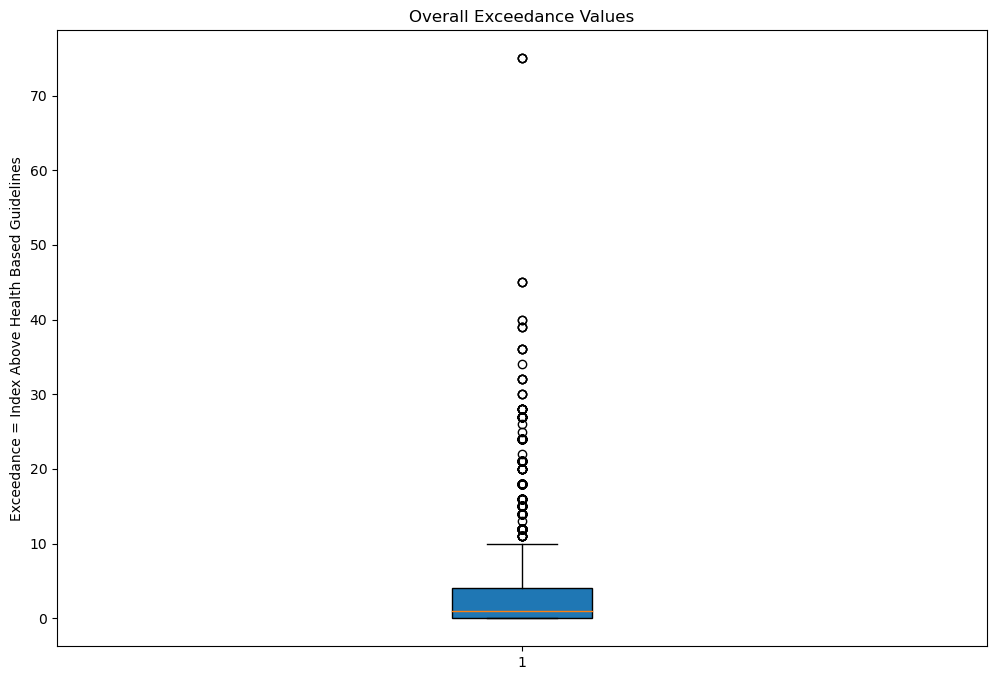

In [8]:
# Create fig and ax object
fg, ax = plt.subplots(figsize=(12,8))

# Create box plot
ax.boxplot(df["exceedance"], vert=True, patch_artist=True)

# set labels and title
ax.set_ylabel("Exceedance = Index Above Health Based Guidelines")

ax.set_title("Overall Exceedance Values")



Text(0.5, 1.0, 'Overall Exceedance Values')

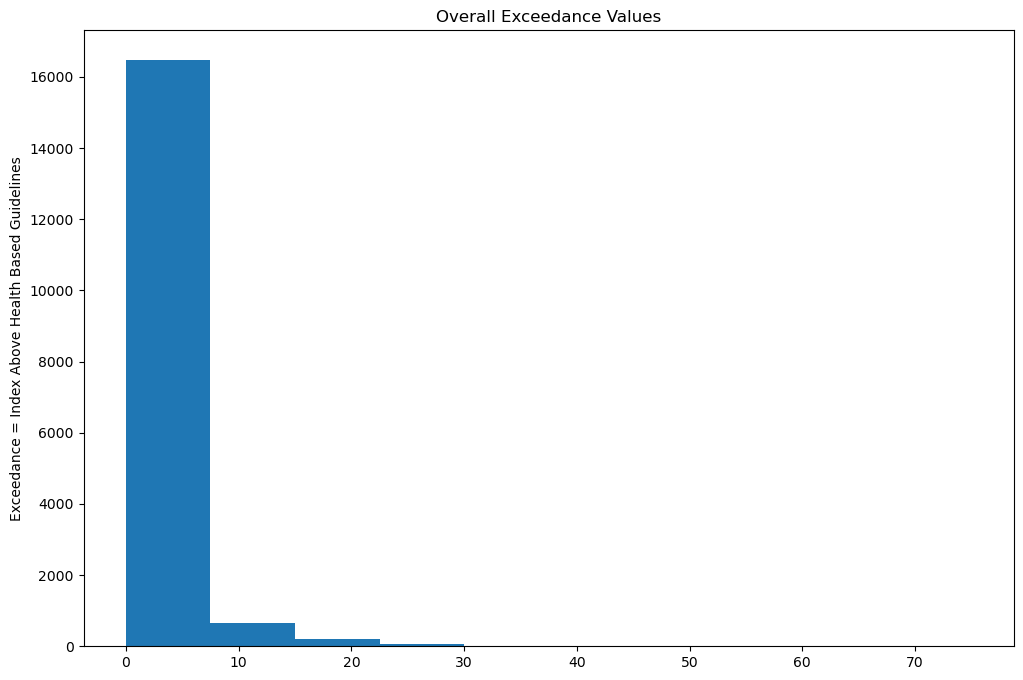

In [9]:
# Create fig and ax object
fg, ax = plt.subplots(figsize=(12,8))

# Create box plot
ax.hist(df["exceedance"])

# set labels and title
ax.set_ylabel("Exceedance = Index Above Health Based Guidelines")

ax.set_title("Overall Exceedance Values")

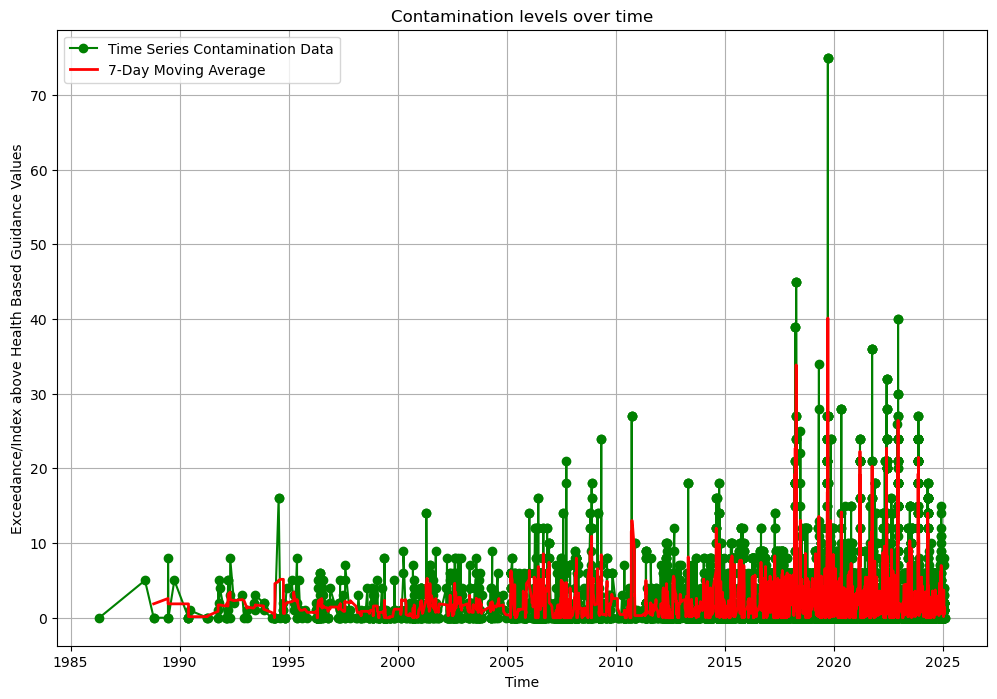

In [10]:
### Set the index and sort by time
df_c= df_c.set_index(df["latest_sam"])
df_c= df_c.sort_index()

# Define a rolling window (e.g., 7-day moving average)
df_c["moving_avg"] = df_c["exceedance"].rolling(window=7, center=True).mean()

fg, ax = plt.subplots(figsize=(12,8))


## Raw data 
ax.plot(df_c["latest_sam"],df_c["exceedance"], marker='o', linestyle='-', color='g',label='Time Series Contamination Data')

# Plot smoothed moving average
ax.plot(df_c["latest_sam"], df_c["moving_avg"], color='r', linewidth=2, label="7-Day Moving Average")

ax.set_xlabel("Time")
ax.set_ylabel("Exceedance/Index above Health Based Guidance Values")
ax.set_title("Contamination levels over time")
ax.legend()
plt.grid(True)
